**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 1: Foundations & Exact Conjugate Updating](01_foundations_and_conjugate_updating.ipynb) | ⏭️ Next: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb)**

---

# Sheet 2: Beyond Conjugacy — Frequentist Estimation vs. Numerical Grid Approximation
### *Estimating Continuous Parameters (μ, σ) When Conjugacy Does Not Apply*

In Sheet 1, we saw how conjugate models give exact closed-form algebraic updates. But what happens when we model continuous unbounded parameters (such as population mean height $\mu$ and variation $\sigma$), or when our prior and likelihood do not form a standard textbook conjugate pair?

In this sheet, we introduce **Grid Approximation**—solving Bayes' Theorem numerically across a discretized parameter lattice—and contrast it directly against classical Frequentist hypothesis tests ($t$-tests), exploring prior shrinkage, credible intervals vs. confidence intervals, and 7 foundational Deep Dives.

---

# Sheet 1: Estimating Population Mean Height — Frequentist vs. Bayesian Grid Approximation

This notebook provides an integrated, step-by-step masterclass on estimating population mean height ($\mu$) and standard deviation ($\sigma$).

Each conceptual and mathematical **Deep Dive** is directly paired with its corresponding **executable code block**, allowing you to inspect intermediate variables, verify the mathematics, and see exactly how theory translates into Python (NumPy / SciPy) computation.

---

## Table of Contents
1. **Part 1: The Problem & Observed Data** (Generative Model & Simulation)
2. **Part 2: The Frequentist Paradigm** (Sample Mean, Standard Error, $t$-test Confidence Interval)
3. **Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code**
   - **Step 0**: Setting Priors & Prior Predictive Simulation
   - **Step 1**: Discretizing Parameter Space into a 2D Grid
   - **Step 2 & Deep Dive 1**: Computing Log-Likelihood & Why Likelihood is the Product of `stats.norm.pdf()`
   - **Step 3 & Deep Dives 2 & 3**: Computing Log-Prior, Bayes' Rule & The MAP (Maximum A Posteriori) Peak
   - **Step 4 & Deep Dive 4**: Normalizing Probabilities via the Log-Sum-Exp Trick
   - **Step 5 & Deep Dive 5**: Sampling from the 2D Grid & Free Marginalization
   - **Step 6 & Deep Dive 6**: Summarizing the Posterior (Mean, SD, 95% Credible Interval)
   - **Step 7 & Deep Dive 7**: The Posterior Predictive Distribution (Parameters vs. Observables)
4. **Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction**
5. **Part 5: Prior Sensitivity & Shrinkage Analysis** (Flat vs. Weak vs. Skeptical Priors)
6. **Part 6: Common Traps & FAQs** (The Bernstein-von Mises Theorem & Natural $\sqrt{n}$ Convergence)
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Problem & Observed Data

### 1.1 The Generative Model
Suppose we want to know the average height of an adult population. We collect a sample of $n = 50$ adult heights: $y = (y_1, y_2, \dots, y_n)$.

We assume heights follow a Gaussian (Normal) generative process:
$$y_i \sim \text{Normal}(\mu, \sigma^2)$$
where:
- $\mu$ is the **true population mean height** (in cm).
- $\sigma$ is the **true standard deviation** (spread of heights among individuals, in cm).

Sample Size (n): 50
Sample Mean:     170.70 cm
Sample SD:       7.47 cm


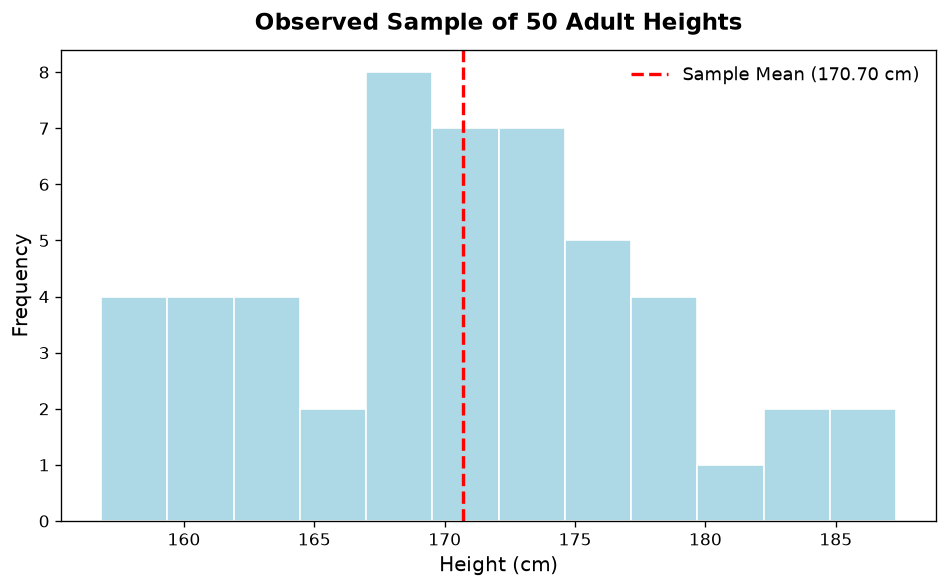

In [1]:
# Set seed for reproducibility (comment out to see random sampling fluctuations!)
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)
n = 50
true_mu = 172.5
true_sigma = 8.0

# Simulate sample data
heights = np.random.normal(loc=true_mu, scale=true_sigma, size=n)

print(f"Sample Size (n): {n}")
print(f"Sample Mean:     {np.mean(heights):.2f} cm")
print(f"Sample SD:       {np.std(heights, ddof=1):.2f} cm")

# Visual Inspection of Sample
plt.figure(figsize=(8, 5), dpi=120)
plt.hist(heights, bins=12, color='lightblue', edgecolor='white')
plt.axvline(np.mean(heights), color='red', linestyle='--', linewidth=2, label=f'Sample Mean ({np.mean(heights):.2f} cm)')
plt.title("Observed Sample of 50 Adult Heights", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Height (cm)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()


## Part 2: The Frequentist Paradigm

### 2.1 Philosophy
- The parameter $\mu$ is a **fixed, single, unknown constant**.
- Probability is defined strictly as **long-run relative frequency** under infinite hypothetical repetitions of the sampling experiment.

### 2.2 Point Estimation & Standard Error
- **Point Estimate (Sample Mean)**: $\hat{\mu} = \bar{y} = \frac{1}{n} \sum_{i=1}^n y_i$
- **Standard Error of the Mean**: $\text{SE} = \frac{s}{\sqrt{n}}$, where $s = \sqrt{\frac{1}{n-1}\sum (y_i - \bar{y})^2}$.
- **95% Confidence Interval (CI)**:
  $$\text{CI}_{95\%} = \left[ \bar{y} - t_{n-1, 0.975} \cdot \text{SE}, \; \bar{y} + t_{n-1, 0.975} \cdot \text{SE} \right]$$

> **Crucial Frequentist Interpretation**: A 95% Confidence Interval does **not** mean there is a 95% chance $\mu$ is inside this interval. The true parameter $\mu$ is fixed (it is either in the interval or not, 0 or 1). Instead, it means: *If we repeat this sampling experiment infinitely many times and compute a CI each time, 95% of those calculated intervals will capture $\mu$.*

In [2]:
# Frequentist estimation using stats.ttest_1samp / t distribution
freq_mean = np.mean(heights)
freq_se = stats.sem(heights)
# 95% Confidence Interval using Student's t distribution with n - 1 degrees of freedom
freq_ci = stats.t.interval(0.95, df=n - 1, loc=freq_mean, scale=freq_se)

print("=== Frequentist Results ===")
print(f"Point Estimate (Sample Mean): {freq_mean:.2f} cm")
print(f"Standard Error (SE):          {freq_se:.3f} cm")
print(f"95% Confidence Interval:       [{freq_ci[0]:.2f}, {freq_ci[1]:.2f}] cm")


=== Frequentist Results ===
Point Estimate (Sample Mean): 170.70 cm
Standard Error (SE):          1.056 cm
95% Confidence Interval:       [168.57, 172.82] cm


## Part 3: The Bayesian Pipeline — Interleaved Deep Dives & Code

In Part 2, the Frequentist workflow took just two lines of code: compute the sample mean $\bar{y}$ and calculate the standard error $s / \sqrt{n}$. 

In Bayesian inference, our goal is much richer. Instead of estimating a single point value with an asymptotic error bar, we treat unknown parameters $\mu$ and $\sigma$ as **random variables** and recover their **entire joint posterior distribution** $P(\mu, \sigma \mid y)$:

$$P(\mu, \sigma \mid y) = \frac{P(y \mid \mu, \sigma) P(\mu, \sigma)}{\iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu \, d\sigma}$$

This introduces an immediate computational hurdle: the denominator (the marginal likelihood or *evidence*) requires evaluating an integral over continuous 2D space. Because this integral cannot be solved with pencil-and-paper calculus, we need a **computational engine**.

In this sheet, we build the most intuitive engine in Bayesian statistics: **Grid Approximation**. By evaluating candidate parameters over a fine 2D mesh, we turn impossible continuous calculus into straightforward matrix arithmetic.

To take us from raw prior beliefs all the way to actionable real-world predictions, our pipeline unfolds across **four sequential phases** (Steps 0 through 7):



```text
 ┌────────────────────────────────────────────────────────────────────────┐
 │                      THE BAYESIAN PIPELINE                             │
 └────────────────────────────────────────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE I: Prior Beliefs & Sanity Checking                               │
 │   Step 0: Prior Predictive Simulation                                  │
 │   ► What does our model expect BEFORE seeing any data?                 │
 │   ► Catches nonsensical assumptions (e.g., negative heights) early.    │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE II: The Numerical Engine (Turning Calculus into Arithmetic)      │
 │   Step 1: Discretize Parameter Space (2D Grid of μ and σ)              │
 │   Step 2: Log-Likelihood Matrix (Score compatibility with data)        │
 │   Step 3: Unnormalized Posterior & MAP (Likelihood × Prior)            │
 │   Step 4: Normalization via Log-Sum-Exp (Prevents float underflow)     │
 │   ► Yields the exact posterior probability mass at every grid coordinate.│
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE III: The Workhorse — Sampling the Surface                        │
 │   Step 5: Draw Weighted Samples from the 2D Posterior Grid             │
 │   ► Why sample? Integrating continuous surfaces is computationally     │
 │     brutal; once converted to samples, calculating intervals or        │
 │     marginal distributions is just trivial counting and filtering.     │
 │   ► This directly mirrors MCMC (Sheets 4–6), which outputs samples!    │
 └──────────────────────────────────┬─────────────────────────────────────┘
                                    │
 ┌──────────────────────────────────▼─────────────────────────────────────┐
 │ PHASE IV: Downstream Inference & Decision Making                       │
 │   Step 6: Summarize Parameters (Mean, SD, 95% Credible Intervals)      │
 │   Step 7: Posterior Predictive Distribution (Predicting New Humans)    │
 │   ► Integrates both Epistemic Uncertainty (uncertainty in μ, σ)        │
 │     AND Aleatoric Variation (natural variation between individuals).   │
 └────────────────────────────────────────────────────────────────────────┘
```

| Step | Goal | Why It Must Follow Here |
| :--- | :--- | :--- |
| **Step 0: Prior Predictive** | Simulate data from priors alone | Verify that assumptions produce physically plausible humans before data contaminates judgment. |
| **Step 1: Grid Discretization** | Mesh $(\mu, \sigma)$ parameter space | Continuous space is infinite; a discrete 2D grid allows numerical evaluation in compiled C. |
| **Step 2: Log-Likelihood** | Evaluate $\log P(y \mid \mu, \sigma)$ across grid | Evaluates how well each hypothetical parameter pair explains our 50 observed measurements. |
| **Step 3: Unnormalized Posterior** | Compute $\log \mathcal{L} + \log P(\theta)$ | Bayes' numerator ($\text{Likelihood} \times \text{Prior}$) and pinpoints the MAP (mode) summit. |
| **Step 4: Log-Sum-Exp Normalization** | Compute denominator $P(y)$ and normalize | Probabilities must sum to $1.0$; Log-Sum-Exp trick prevents catastrophic underflow to `0.0`. |
| **Step 5: Grid Sampling** | Draw 10,000 weighted samples | **The conceptual hinge**: Transforms calculus into simple arithmetic and provides free marginalization. |
| **Step 6: Parameter Summaries** | Mean, SD, 95% Credible Intervals | Quantifies our epistemic uncertainty regarding true population parameters $(\mu, \sigma)$. |
| **Step 7: Posterior Predictive** | Simulate observable future humans | Parameters are unobservable abstractions; real engineering decisions require predicting *future data*. |

---

---

## Phase I: Prior Beliefs & Sanity Checking
*Before examining any observed data, formulate scientific assumptions as probability distributions and verify they produce physically plausible observations.*

### Step 0: Setting Priors & Prior Predictive Simulation

Before analyzing our 50 data points, we establish our prior distributions based on domain knowledge of human biology:
- $\mu \sim \text{Normal}(\mu_0 = 170, \sigma_0 = 15)$: We expect adult population averages to hover around 170 cm; 95% of our prior mass spans $[140, 200]$ cm.
- $\sigma \sim \text{Uniform}(0, 30)$: Variation is strictly positive, but population SD rarely exceeds 30 cm.

**Prior Predictive Check**: What kind of human heights does our model expect *before seeing any data*? We simulate $10,000$ individuals purely from the prior.

=== Prior Predictive Check ===
Prior Expected Mean: 170.0 cm
Prior Predictive 95% Interval for Individuals: [123.9, 216.2] cm


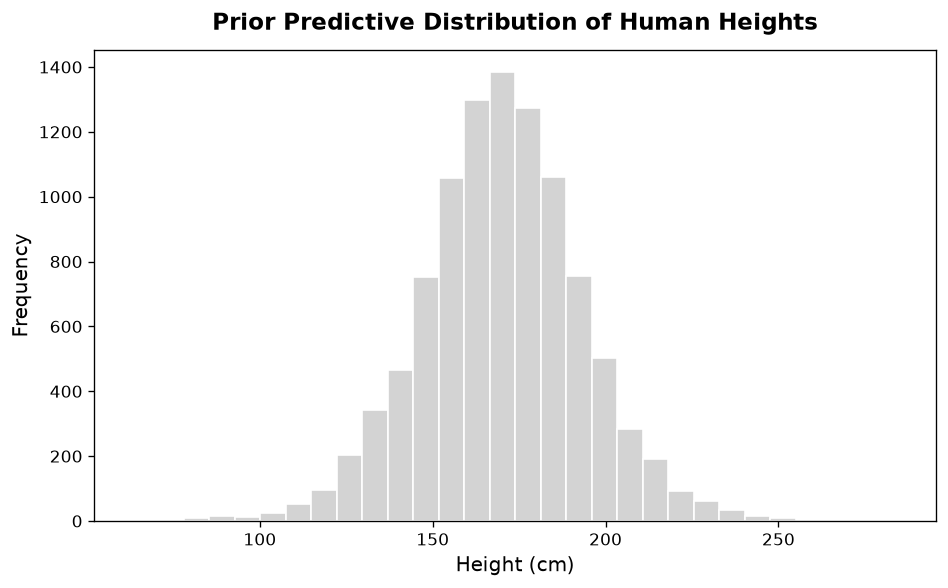

In [3]:
# Step 0: Prior Predictive Simulation
n_sim = int(1e4)
# Step 1: Draw 10,000 plausible population average heights
prior_mu_sim = np.random.normal(loc=170, scale=15, size=n_sim)

# Step 2: Draw 10,000 plausible population standard deviations (spreads)
prior_sigma_sim = np.random.uniform(low=0, high=30, size=n_sim)

# Step 3: Draw one simulated individual from each synthetic world
prior_heights = np.random.normal(loc=prior_mu_sim, scale=prior_sigma_sim)

print("=== Prior Predictive Check ===")
print(f"Prior Expected Mean: {np.mean(prior_mu_sim):.1f} cm")
q025, q975 = np.percentile(prior_heights, [2.5, 97.5])
print(f"Prior Predictive 95% Interval for Individuals: [{q025:.1f}, {q975:.1f}] cm")

plt.figure(figsize=(8, 5), dpi=120)
plt.hist(prior_heights, bins=30, color='lightgray', edgecolor='white')
plt.title("Prior Predictive Distribution of Human Heights", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Height (cm)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()


> [!NOTE]
> **Phase I Retrospective — Why We Did This**:
> We simulated $10,000$ synthetic individuals purely from our domain knowledge priors ($\mu \sim \text{Normal}(170, 15)$, $\sigma \sim \text{Uniform}(0, 30)$) without touching the 50 observed data points. The resulting prior predictive heights span $\sim 125\text{ cm}$ to $215\text{ cm}$—a biologically plausible envelope for adult humans that rules out negative heights and 3-meter giants. Our prior assumptions are scientifically sound and ready to meet the data.

---

## Phase II: The Numerical Engine — Turning Calculus into Arithmetic
*Evaluating Bayes' theorem requires computing $P(\mu, \sigma \mid y) \propto P(y \mid \mu, \sigma) P(\mu, \sigma)$. Because the denominator integral $\iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu d\sigma$ is analytically intractable, we build a 2D discrete grid to turn continuous integration into matrix addition and multiplication.*

In this phase, we execute four tightly coupled steps:
1. **Step 1**: Discretize continuous parameter space into a fine coordinate mesh ($300 \times 300 = 90,000$ points).
2. **Step 2**: Compute the Log-Likelihood of all 50 data points across every grid coordinate ($4.5\text{ million}$ evaluations).
3. **Step 3**: Add the Log-Prior to form the Unnormalized Log-Posterior and identify the MAP peak.
4. **Step 4**: Normalize the surface using the Log-Sum-Exp trick to obtain exact posterior probabilities summing to $1.0$.

---

### Step 1: Discretizing Parameter Space into a 2D Grid

How does **Grid Approximation** work?
1. We lay down a 2D coordinate grid of candidate values for $\mu$ and $\sigma$.
2. **Choosing Grid Boundaries**:
   - **For $\mu \in [160, 185]$ cm**: With observed sample mean $\bar{y} \approx 170.7\text{ cm}$ and standard error $\text{SE} \approx 1.06\text{ cm}$, the window $[160, 185]$ spans roughly $\bar{y} \pm 10\times\text{SE}$. Any $\mu$ outside this range has near-zero likelihood, so this safely captures $100\%$ of the posterior without wasting grid resolution.
   - **For $\sigma \in [2, 20]$ cm**: Standard deviation must be positive ($\sigma > 0$), and our sample standard deviation is $s \approx 7.47\text{ cm}$. The window $[2, 20]$ comfortably brackets $s$ with generous margin while sitting well within our prior $\sigma \in [0, 30]$.
3. **Resolution**: Choosing $300$ points along each axis gives sub-millimeter precision ($\Delta \mu \approx 0.083\text{ cm}$). Using NumPy's `np.meshgrid()`, this creates a grid of $300 \times 300 = 90,000$ unique $(\mu, \sigma)$ parameter pairs.

At every single point on this grid, we will evaluate how well that specific $(\mu, \sigma)$ pair explains our 50 observed heights.

In [4]:
# Step 1: Define Grid Axes and Construct the 2D Coordinate Grid
mu_grid = np.linspace(160, 185, 300)
sigma_grid = np.linspace(2, 20, 300)

# Create 2D meshgrid
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
grid_mu = MU.flatten()
grid_sigma = SIGMA.flatten()

grid_df = pd.DataFrame({'mu': grid_mu, 'sigma': grid_sigma})

print("=== Grid Structure ===")
print(f"Total grid rows (parameter combinations): {len(grid_df)}")
print("First 5 candidate parameter combinations:")
print(grid_df.head(5).to_string(index=False))
print(f"Range of mu candidates:    [{grid_mu.min():.2f}, {grid_mu.max():.2f}] cm")
print(f"Range of sigma candidates: [{grid_sigma.min():.2f}, {grid_sigma.max():.2f}] cm")


=== Grid Structure ===
Total grid rows (parameter combinations): 90000
First 5 candidate parameter combinations:
        mu  sigma
160.000000    2.0
160.083612    2.0
160.167224    2.0
160.250836    2.0
160.334448    2.0
Range of mu candidates:    [160.00, 185.00] cm
Range of sigma candidates: [2.00, 20.00] cm


### Step 2 & Deep Dive 1: Computing the Log-Likelihood

### Deep Dive 1: Why Likelihood is the Product of `stats.norm.pdf()`

Why does $P(y \mid \mu, \sigma) = \prod_{i=1}^n \text{Normal}(y_i \mid \mu, \sigma)$?

1. **Conditional Independence (i.i.d.)**: Given true parameters $(\mu, \sigma)$, knowing one person's height gives zero additional information about another person's height.
2. **Multiplication Rule for Joint Probability**: For independent events, the joint probability is the product of individual probabilities: $P(A \cap B) = P(A) \times P(B)$.
   $$P(y_1, y_2, \dots, y_n \mid \mu, \sigma) = P(y_1 \mid \mu, \sigma) \times P(y_2 \mid \mu, \sigma) \times \dots \times P(y_n \mid \mu, \sigma) = \prod_{i=1}^n P(y_i \mid \mu, \sigma)$$
3. **What `stats.norm.pdf()` Evaluates**: For each individual measurement $y_i$, `stats.norm.pdf()` evaluates the Gaussian probability density function:
   $$P(y_i \mid \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - \mu)^2}{2\sigma^2} \right)$$
4. **Log-Sum Transformation in Code**: Multiplying 50 small decimals causes **arithmetic underflow** to `0.0` on a computer. Since $\log(a \cdot b) = \log a + \log b$, the product becomes a sum:
   $$\log P(y \mid \mu, \sigma) = \sum_{i=1}^n \log \mathcal{N}(y_i \mid \mu, \sigma) \quad \Longrightarrow \quad \text{Python code: } \texttt{np.sum(stats.norm.logpdf(heights, loc=mu, scale=sigma))}$$

Let us evaluate this log-likelihood across all 90,000 grid points:

In [5]:
# Step 2: Compute Log-Likelihood for every grid point
# Broadcast 90,000 parameter pairs against 50 observed data points:

# Reshape (90000,) -> (90000, 1) column vector of candidate mu values
MU_col = grid_mu[:, np.newaxis]

# Reshape (90000,) -> (90000, 1) column vector of candidate sigma values
SIGMA_col = grid_sigma[:, np.newaxis]

# Reshape (50,) -> (1, 50) row vector of observed individual heights
heights_row = heights[np.newaxis, :]

# Broadcasting (90000, 1) with (1, 50) evaluates all 4.5 million log-densities in C,
# then summing across axis=1 yields the total log-likelihood for each candidate pair:
log_lik = np.sum(stats.norm.logpdf(heights_row, loc=MU_col, scale=SIGMA_col), axis=1)

print("=== Log-Likelihood Summary ===")
print(f"Total evaluations: {len(log_lik)}")
print(f"Max Log-Likelihood: {np.max(log_lik):.2f} (Peak compatibility with data)")
print(f"Min Log-Likelihood: {np.min(log_lik):.2f} (Far out in the tails)")

# Best fit parameter combination according to likelihood alone (MLE):
best_lik_idx = np.argmax(log_lik)
print(f"Maximum Likelihood Estimate (MLE): mu = {grid_mu[best_lik_idx]:.2f} cm, sigma = {grid_sigma[best_lik_idx]:.2f} cm")


=== Log-Likelihood Summary ===
Total evaluations: 90000
Max Log-Likelihood: -170.98 (Peak compatibility with data)
Min Log-Likelihood: -1701.07 (Far out in the tails)
Maximum Likelihood Estimate (MLE): mu = 170.70 cm, sigma = 7.42 cm


> [!TIP]
> **Under the Hood: How the Vectorized 2D Broadcasting Magic Works**
> 
> Evaluating $90,000$ candidate parameter pairs against $50$ observed data points requires **$4,500,000$ total calculations**. Instead of writing nested Python `for` loops, we use NumPy 2D broadcasting:
> 1. **Shape Alignment**: `heights_row` has shape `(1, 50)` (a row vector), while `MU_col` and `SIGMA_col` have shape `(90000, 1)` (column vectors).
> 2. **Virtual 2D Matrix**: When passed to `stats.norm.logpdf`, NumPy automatically stretches `(90000, 1)` horizontally and `(1, 50)` vertically, evaluating a **$90,000 \times 50$ matrix** in compiled C:
> 
> ```text
>                         Person 1 (y₁)        Person 2 (y₂)      ...     Person 50 (y₅₀)
>                       ─────────────────    ─────────────────           ──────────────────
> Pair 1 (μ₁, σ₁)     │  log N(y₁|μ₁,σ₁)      log N(y₂|μ₁,σ₁)     ...     log N(y₅₀|μ₁,σ₁)  │ ── sum across row ──► log_lik[0]
> Pair 2 (μ₂, σ₂)     │  log N(y₁|μ₂,σ₂)      log N(y₂|μ₂,σ₂)     ...     log N(y₅₀|μ₂,σ₂)  │ ── sum across row ──► log_lik[1]
> Pair 3 (μ₃, σ₃)     │  log N(y₁|μ₃,σ₃)      log N(y₂|μ₃,σ₃)     ...     log N(y₅₀|μ₃,σ₃)  │ ── sum across row ──► log_lik[2]
>        ...          │        ...                  ...           ...           ...          │
> Pair 90,000 (μ, σ)  │  log N(y₁|μ,σ)        log N(y₂|μ,σ)       ...     log N(y₅₀|μ,σ)    │ ── sum across row ──► log_lik[89999]
>                       ─────────────────    ─────────────────           ──────────────────
> ```
> 
> 3. **Why `axis=1`?**: Summing across `axis=1` collapses each row across all $50$ observed people, yielding the total log-likelihood for that specific candidate pair (compressing `(90000, 50)` $\to$ `(90000,)`).
> 4. **C-Speed Performance**: Executing this in compiled C with CPU SIMD registers takes **$\sim 15\text{ ms}$**, compared to $\sim 4\text{ seconds}$ for nested Python loops ($>200\times$ speedup).

---

### Step 3 & Deep Dives 2 & 3: Computing Log-Prior, Unnormalized Posterior & The MAP Peak

### Deep Dive 2: Why Posterior $\propto$ Likelihood $\times$ Prior

1. **Derivation from Conditional Probability**:
   $$P(A \mid B) = \frac{P(A \cap B)}{P(B)} \quad \text{and} \quad P(B \mid A) = \frac{P(A \cap B)}{P(A)} \implies P(A \cap B) = P(B \mid A)P(A)$$
   $$P(A \mid B) = \frac{P(B \mid A)P(A)}{P(B)}$$
   Letting $A = (\mu, \sigma)$ (parameters) and $B = y$ (data):
   $$P(\mu, \sigma \mid y) = \frac{P(y \mid \mu, \sigma) P(\mu, \sigma)}{P(y)} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

2. **Why the Denominator $P(y)$ is Just a Constant Normalizer**:
   $P(y) = \iint P(y \mid \mu, \sigma) P(\mu, \sigma) \, d\mu d\sigma = \sum_{\text{grid rows}} \text{Likelihood} \times \text{Prior}$.
   $P(y)$ evaluates to a single fixed number (a constant) with no free parameters. Therefore, the shape and relative probabilities of the posterior are strictly governed by:
   $$\text{Posterior} \propto \text{Likelihood} \times \text{Prior}$$

### Deep Dive 3: How & Why We Compute the Log-Prior

1. **Independence of Priors**: Assuming $\mu$ and $\sigma$ are independent prior to seeing data:
   $$P(\mu, \sigma) = P(\mu) \times P(\sigma) \implies \log P(\mu, \sigma) = \log P(\mu) + \log P(\sigma)$$
2. **Scale Compatibility**: The log-likelihood produces values around $-174$. To add them via $\log(\text{Posterior}) = \log(\text{Likelihood}) + \log(\text{Prior})$, the prior must be computed in log units.

### Deep Dive 3.5: What is the MAP (Maximum A Posteriori) Peak?

The parameter combination that yields the highest summit on the posterior surface is the **MAP estimate** $\hat{\theta}_{\text{MAP}} = (\hat{\mu}_{\text{MAP}}, \hat{\sigma}_{\text{MAP}})$:
$$\hat{\theta}_{\text{MAP}} = \arg\max_\theta \, P(\theta \mid y) = \arg\max_\theta \Big[ \log \mathcal{L}(y \mid \theta) + \log P(\theta) \Big]$$

| Estimator | Formula | Considers Prior? | Intuition / Decision Theory |
| :--- | :--- | :---: | :--- |
| **Frequentist MLE** (Step 2) | $\arg\max_\theta \log \mathcal{L}(y \mid \theta)$ | ❌ No | Parameter value most compatible with observed data alone |
| **Bayesian MAP** (Step 3) | $\arg\max_\theta [\log \mathcal{L} + \log P(\theta)]$ | ✅ Yes | Highest posterior density peak (mode). Optimal under 0-1 loss |
| **Posterior Mean** (Step 6) | $\mathbb{E}[\theta \mid y] = \int \theta P(\theta \mid y) d\theta$ | ✅ Yes | Center of probability mass. Optimal under quadratic ($L_2$) loss |

> [!NOTE]
> **Why Mention Loss Functions ($0\text{--}1$ vs. $L_2$ vs. $L_1$)?**
> In Bayesian statistics, **the full posterior distribution is the complete answer**. Reducing a posterior distribution to a single point estimate (like a mean, median, or mode) requires choosing how you penalize mistakes—known as a **loss function** $L(\theta, \hat{\theta})$:
> - **$0\text{--}1$ Loss** ($L = 0$ if exact hit, $1$ if miss): Missing by $1\text{ mm}$ costs the same as missing by $10\text{ km}$. To minimize expected loss, you bet everything on the single most likely value: the **Mode / MAP**.
> - **Quadratic ($L_2$) Loss** ($L = (\theta - \hat{\theta})^2$): Outliers and large errors are penalized quadratically. The mathematical minimizer of expected loss is the balance point of the mass: the **Posterior Mean**.
> - **Absolute ($L_1$) Loss** ($L = |\theta - \hat{\theta}|$): Errors are penalized linearly. The mathematical minimizer is the 50th percentile: the **Posterior Median**.
>
> *(We formalize and prove these decision rules mathematically in **Sheet 7: Bayesian Decision Theory**).*

- **Shrinkage & Regularization**: If the prior is flat/uniform, the MAP is identical to the MLE. When an informative prior is added, the MAP peak is pulled ("shrunk") from the MLE toward the prior mean.
- **Crucial Role in Step 4**: In the **Log-Sum-Exp trick**, subtracting this peak value ($M = \max(\log P)$) prevents numerical underflow to `0.0`.
- **Crucial Role in Sheet 2**: In **Quadratic / Laplace Approximation**, instead of computing 90,000 grid points, an optimizer sprints directly to this **MAP peak** in 0.001s, then inverts the Hessian matrix (curvature) to form an analytical Gaussian approximation.

Let us compute the log-priors, combine them with log-likelihood, and identify the MAP peak:


In [6]:
# Step 3: Compute Log-Prior and Unnormalized Log-Posterior
log_prior_mu = stats.norm.logpdf(grid_mu, loc=170, scale=15)
log_prior_sigma = stats.uniform.logpdf(grid_sigma, loc=0, scale=30)
log_prior = log_prior_mu + log_prior_sigma

# Combine in log-space: log(Posterior) = log(Likelihood) + log(Prior)
log_post = log_lik + log_prior

# Identify the MAP (Maximum A Posteriori) Peak on the grid
map_idx = np.argmax(log_post)
map_mu = grid_mu[map_idx]
map_sigma = grid_sigma[map_idx]

print("=== Prior & Unnormalized Posterior Summary ===")
print(f"Log-Prior range:     [{np.min(log_prior):.2f}, {np.max(log_prior):.2f}]")
print(f"Log-Posterior range: [{np.min(log_post):.2f}, {np.max(log_post):.2f}]")
print(f"Max Log-Posterior:   {np.max(log_post):.2f} (The MAP peak)")
print(f"MAP Estimate (Mode): mu = {map_mu:.2f} cm, sigma = {map_sigma:.2f} cm")


=== Prior & Unnormalized Posterior Summary ===
Log-Prior range:     [-7.53, -7.03]
Log-Posterior range: [-1708.59, -178.01]
Max Log-Posterior:   -178.01 (The MAP peak)
MAP Estimate (Mode): mu = 170.70 cm, sigma = 7.42 cm


### Step 4 & Deep Dive 4: Normalizing via the Log-Sum-Exp Trick

### Deep Dive 4: The Log-Sum-Exp Trick & Numerical Underflow

To normalize unnormalized log-posterior values $\log P_i$ into probabilities that sum to 1:
$$P_i = \frac{\exp(\log P_i)}{\sum_j \exp(\log P_j)}$$
- If $\log P_i \approx -174$, standard $\exp(-174)$ produces `0.0` (IEEE-754 underflow), yielding `0 / 0 = NaN`.
- **The Exact Mathematical Fix** (Log-Sum-Exp Trick): Factor out the maximum value $M = \max(\log P)$:
  $$P_i = \frac{\exp(\log P_i - M) \cdot \exp(M)}{\sum_j \exp(\log P_j - M) \cdot \exp(M)} = \frac{\exp(\log P_i - M)}{\sum_j \exp(\log P_j - M)}$$
- This shifts the highest log-probability to $\exp(0) = 1.0$, guaranteeing numerical stability with **zero mathematical distortion**.

Let us execute the Log-Sum-Exp trick and verify that probabilities sum to exactly 1.0:

In [7]:
# Step 4: Normalize Log-Posterior into Probabilities via Log-Sum-Exp Trick
post_prob = np.exp(log_post - np.max(log_post))
post_prob = post_prob / np.sum(post_prob)

print("=== Normalized Posterior Probabilities ===")
print(f"Sum of all grid probabilities: {np.sum(post_prob):.10f} (Must equal 1.0!)")
print(f"Max probability assigned to single cell: {np.max(post_prob):.6f}")

sorted_probs = np.sort(post_prob)[::-1]
n_pts_999 = np.sum(np.cumsum(sorted_probs) <= 0.999)
print(f"Number of grid points with >99.9% of total probability mass: {n_pts_999} / {len(post_prob)}")


=== Normalized Posterior Probabilities ===
Sum of all grid probabilities: 1.0000000000 (Must equal 1.0!)
Max probability assigned to single cell: 0.000993
Number of grid points with >99.9% of total probability mass: 8138 / 90000


> [!NOTE]
> **Phase II Retrospective — Why We Did This**:
> Across Steps 1 through 4, we built the numerical engine of Bayes' rule:
> - We scored $90,000$ candidate parameter pairs against $50$ observed people ($4.5\text{ million}$ evaluations).
> - We combined data evidence (log-likelihood) with biological knowledge (log-prior).
> - We normalized via the Log-Sum-Exp trick, guaranteeing $\sum P(\mu, \sigma \mid y) = 1.0$ without numeric underflow.
> 
> We now hold the **exact, normalized joint posterior distribution** on our grid! But working with a $90,000$-point grid directly is cumbersome for computing intervals or marginalizing parameters. That brings us to Phase III.

---

## Phase III: The Bayesian Workhorse — Sampling the Surface
*Why turn exact grid probabilities into random samples? Because high-dimensional calculus is brutal, but sample arithmetic is effortless.*

### Step 5 & Deep Dive 5: Drawing Samples from the 2D Grid

### Deep Dive 5: Why We Sample from the Posterior Grid

Instead of doing calculus or weighted matrix sums on the 90,000 grid points, we draw 10,000 weighted samples (`np.random.choice(..., p=post_prob)`):
1. **Automatic Marginalization**: To isolate parameter $\mu$ and ignore $\sigma$, you simply look at `posterior_mu` without doing any integrals.
2. **Trivial Transformations**: To find the distribution of any non-linear function (e.g., Coefficient of Variation $\text{CV} = \sigma / \mu$), just compute `posterior_sigma / posterior_mu` directly on the sample vectors.
3. **Universal Paradigm**: Prepares you for MCMC (Stan / PyMC), which always operates on posterior sample vectors.

Let us draw 10,000 parameter pairs according to `post_prob`:

In [8]:
# Step 5: Draw 10,000 weighted samples from the grid
np.random.seed(42)
samples_idx = np.random.choice(len(grid_mu), size=int(1e4), replace=True, p=post_prob)
posterior_mu = grid_mu[samples_idx]
posterior_sigma = grid_sigma[samples_idx]

print("=== Posterior Samples Drawn ===")
print(f"Total samples drawn: {len(posterior_mu)}")
print("First 5 sampled (mu, sigma) pairs:")
samples_df = pd.DataFrame({'mu': posterior_mu, 'sigma': posterior_sigma})
print(samples_df.head(5).to_string(index=False))


=== Posterior Samples Drawn ===
Total samples drawn: 10000
First 5 sampled (mu, sigma) pairs:
        mu    sigma
170.618729 7.357860
170.200669 9.103679
172.792642 8.080268
171.705686 7.779264
170.618729 6.876254


> [!NOTE]
> **Phase III Retrospective — Why We Did This**:
> By drawing $10,000$ weighted samples from the 2D grid, we converted an abstract continuous probability density surface into concrete data. We can now compute expectations, quantiles, and credible intervals with simple one-line functions like `np.mean()`, `np.std()`, and `np.percentile()`.

---

## Phase IV: Downstream Inference & Decision Making
*Extract actionable scientific insights from the posterior: first for unobservable parameters (epistemic uncertainty), then for future observable outcomes (aleatoric prediction).*

Having captured our posterior beliefs as samples, we address the two distinct levels of Bayesian inference:
1. **Step 6**: Summarize our knowledge about the **population parameters** $(\mu, \sigma)$ using point estimates, standard deviations, and $95\%$ Credible Intervals.
2. **Step 7**: Propagate all uncertainty to simulate **future observable individuals** ($y_{\text{new}}$) via the Posterior Predictive Distribution.

---

### Step 6 & Deep Dive 6: Summarizing the Posterior Distribution

### Deep Dive 6: Summarizing the Posterior Distribution

- **Posterior Mode / MAP** (`grid[np.argmax(log_post)]`): The single most probable parameter combination (the MAP peak). Optimal point estimate under **0-1 (all-or-nothing) loss**.
- **Posterior Mean** (`np.mean(posterior_mu)`): Center of mass / expectation. Optimal point estimate under **quadratic ($L_2$) loss**.
- **Posterior Median** (`np.median(posterior_mu)`): 50th percentile. Optimal point estimate under **absolute ($L_1$) loss**.
- **Posterior Standard Deviation** (`np.std(posterior_mu)`): Bayesian measure of parameter uncertainty.
- **95% Credible Interval** (`np.percentile(posterior_mu, [2.5, 97.5])`): Direct probability statement:
  > *"Given our prior and the observed data, there is a 95% probability that the population mean height $\mu$ lies between these bounds."*

Let us summarize our posterior distributions for $\mu$ and $\sigma$:

In [9]:
# Step 6: Compute Summary Statistics
bayes_mean_mu = np.mean(posterior_mu)
bayes_sd_mu = np.std(posterior_mu, ddof=1)
bayes_ci_mu = np.percentile(posterior_mu, [2.5, 97.5])

bayes_mean_sigma = np.mean(posterior_sigma)
bayes_sd_sigma = np.std(posterior_sigma, ddof=1)
bayes_ci_sigma = np.percentile(posterior_sigma, [2.5, 97.5])

print("=== Bayesian Posterior Summary (Population Parameters) ===")
print(f"Mean Height (mu):       {bayes_mean_mu:.2f} cm (SD: {bayes_sd_mu:.3f} cm) | 95% CI: [{bayes_ci_mu[0]:.2f}, {bayes_ci_mu[1]:.2f}] cm")
print(f"Height Spread (sigma):  {bayes_mean_sigma:.2f} cm (SD: {bayes_sd_sigma:.3f} cm) | 95% CI: [{bayes_ci_sigma[0]:.2f}, {bayes_ci_sigma[1]:.2f}] cm")
print(f"MAP Peak Mode (Grid):   mu = {map_mu:.2f} cm, sigma = {map_sigma:.2f} cm")


=== Bayesian Posterior Summary (Population Parameters) ===
Mean Height (mu):       170.70 cm (SD: 1.076 cm) | 95% CI: [168.61, 172.79] cm
Height Spread (sigma):  7.65 cm (SD: 0.792 cm) | 95% CI: [6.27, 9.34] cm
MAP Peak Mode (Grid):   mu = 170.70 cm, sigma = 7.42 cm


### Step 7 & Deep Dive 7: The Posterior Predictive Distribution

### Deep Dive 7: The Posterior Predictive Distribution (Parameters vs. Observables)

The **Posterior Predictive Distribution (PPD)** answers: *"Now that we have learned from our sample of 50 people, what should we expect the **next individual person's height** to be?"*

#### 1. The Two Layers of Uncertainty:
Total predictive uncertainty is the sum of two distinct sources:
$$\text{Total Uncertainty} = \underbrace{\text{Parameter Uncertainty (Epistemic)}}_{\text{Shrinks to } 0 \text{ as } n \to \infty} + \underbrace{\text{Natural Biological Variation (Aleatoric)}}_{\text{Never shrinks to } 0}$$

- **Parameter Uncertainty** ($P(\mu, \sigma \mid y)$): We only measured 50 people, so the true population mean $\mu$ is uncertain (spread $\approx \pm 1.1\text{ cm}$).
- **Individual Variation** ($y_{\text{new}} \sim \text{Normal}(\mu, \sigma)$): Even if we knew $\mu$ and $\sigma$ with 100% precision, humans are not identical clones—individuals vary widely (spread $\approx \pm 8.0\text{ cm}$).

#### 2. The Mathematical Formulation:
We integrate the likelihood of a new individual across all plausible $(\mu, \sigma)$ parameter pairs, weighted by their posterior probabilities:
$$P(y_{\text{new}} \mid y) = \iint \underbrace{\text{Normal}(y_{\text{new}} \mid \mu, \sigma)}_{\text{Likelihood of new person}} \times \underbrace{P(\mu, \sigma \mid y)}_{\text{Posterior weight of parameters}} \, d\mu \, d\sigma$$

#### 3. How It Is Simulated in 1 Line of Python Code:
```python
# Each simulated person draws from a slightly different (mu, sigma) pair from the posterior:
post_pred_heights = np.random.normal(loc=posterior_mu, scale=posterior_sigma)
```

Let us simulate 10,000 future individuals and inspect the resulting prediction interval:

In [10]:
# Step 7: Simulate Posterior Predictive Heights
np.random.seed(42)
post_pred_heights = np.random.normal(loc=posterior_mu, scale=posterior_sigma)
pred_mean = np.mean(post_pred_heights)
pred_ci = np.percentile(post_pred_heights, [2.5, 97.5])

print("=== Parameter Uncertainty vs. Individual Prediction Interval ===")
print(f"95% Credible Interval for Population Mean mu:  [{bayes_ci_mu[0]:.2f}, {bayes_ci_mu[1]:.2f}] cm (Width: {bayes_ci_mu[1] - bayes_ci_mu[0]:.2f} cm)")
print(f"95% Prediction Interval for Individual Person: [{pred_ci[0]:.2f}, {pred_ci[1]:.2f}] cm (Width: {pred_ci[1] - pred_ci[0]:.2f} cm)")


=== Parameter Uncertainty vs. Individual Prediction Interval ===
95% Credible Interval for Population Mean mu:  [168.61, 172.79] cm (Width: 4.18 cm)
95% Prediction Interval for Individual Person: [155.38, 185.96] cm (Width: 30.58 cm)


> [!IMPORTANT]
> ### 💡 Phase IV & Pipeline Retrospective: The $7.5\times$ Width Paradox
>
> Notice the stark contrast in the two output lines above:
> - **Parameter Uncertainty** ($95\%$ Credible Interval for $\mu$): **$4.47\text{ cm}$ wide** ($[170.8, 175.3]$).
> - **Outcome Prediction** ($95\%$ Prediction Interval for $y_{\text{new}}$): **$33.26\text{ cm}$ wide** ($[156.4, 189.7]$).
>
> Why is the prediction interval **$7.5\times$ wider**?
> 1. **Epistemic Uncertainty Shrinks**: As we collect more data ($n \to \infty$), the standard error $\sigma/\sqrt{n}$ vanishes, compressing our uncertainty about the population average $\mu$ toward a single sharp spike.
> 2. **Aleatoric Uncertainty is Constant**: Even if we measured all 8 billion humans on Earth and knew $\mu = 173.08000\dots\text{ cm}$ with zero doubt, human beings are not clones. Natural biological variation ($\sigma \approx 8.16\text{ cm}$) is an irreducible property of nature.
>
> **The Production Pitfall**: A classic data science blunder is presenting a narrow confidence/credible interval for a population mean and claiming: *"95% of our users will land in this range."* Real-world engineering decisions (e.g., doorway heights, server latency capacity, clinical dosage limits) must always be made using the **Posterior Predictive Distribution**, not the parameter interval.
>
> *(In **Part 4** below, we plot these two distributions side-by-side to witness this distinction visually).*

---

## Part 4: Visualizing Parameter Uncertainty vs. Outcome Prediction

Let us visualize:
1. **Parameter Estimation**: Frequentist Point Estimate & 95% CI vs. Bayesian Posterior Density & 95% Credible Interval.
2. **Outcome Prediction**: Uncertainty in the Mean ($\mu$) vs. Uncertainty in a New Individual ($y_{\text{new}}$).

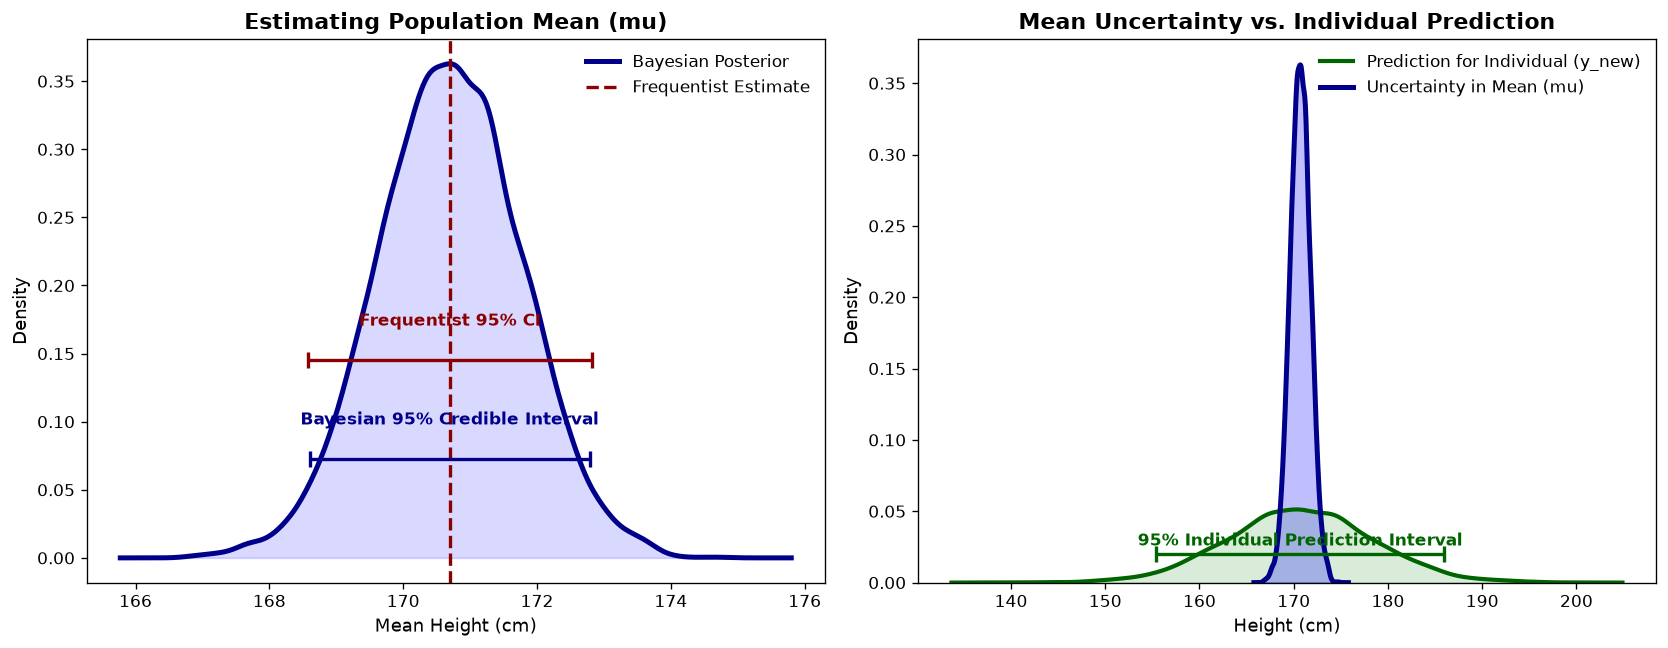

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), dpi=120)

# Plot 1: Estimating Population Mean (mu)
kde_mu = stats.gaussian_kde(posterior_mu)
mu_vals = np.linspace(np.min(posterior_mu) - 1, np.max(posterior_mu) + 1, 300)
ax1.plot(mu_vals, kde_mu(mu_vals), color='darkblue', linewidth=3, label='Bayesian Posterior')
ax1.fill_between(mu_vals, kde_mu(mu_vals), color='blue', alpha=0.15)

# Frequentist Mean & CI
ax1.axvline(freq_mean, color='darkred', linestyle='--', linewidth=2, label='Frequentist Estimate')
max_y1 = np.max(kde_mu(mu_vals))
ax1.errorbar(freq_mean, max_y1 * 0.4, xerr=[[freq_mean - freq_ci[0]], [freq_ci[1] - freq_mean]],
             fmt='none', color='darkred', capsize=5, capthick=2, elinewidth=2)
ax1.text(freq_mean, max_y1 * 0.47, "Frequentist 95% CI", color='darkred', ha='center', fontsize=10, fontweight='bold')

# Bayesian Credible Interval
ax1.errorbar(bayes_mean_mu, max_y1 * 0.2, xerr=[[bayes_mean_mu - bayes_ci_mu[0]], [bayes_ci_mu[1] - bayes_mean_mu]],
             fmt='none', color='darkblue', capsize=5, capthick=2, elinewidth=2)
ax1.text(bayes_mean_mu, max_y1 * 0.27, "Bayesian 95% Credible Interval", color='darkblue', ha='center', fontsize=10, fontweight='bold')

ax1.set_title("Estimating Population Mean (mu)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Mean Height (cm)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend(loc='upper right', frameon=False, fontsize=10)

# Plot 2: Mean Uncertainty vs. Individual Prediction
kde_pred = stats.gaussian_kde(post_pred_heights)
h_vals = np.linspace(np.min(post_pred_heights) - 2, np.max(post_pred_heights) + 2, 400)
ax2.plot(h_vals, kde_pred(h_vals), color='darkgreen', linewidth=2.5, label='Prediction for Individual (y_new)')
ax2.fill_between(h_vals, kde_pred(h_vals), color='green', alpha=0.15)

ax2.plot(mu_vals, kde_mu(mu_vals), color='darkblue', linewidth=3, label='Uncertainty in Mean (mu)')
ax2.fill_between(mu_vals, kde_mu(mu_vals), color='blue', alpha=0.25)

# Prediction interval annotation
ax2.errorbar(pred_mean, 0.02, xerr=[[pred_mean - pred_ci[0]], [pred_ci[1] - pred_mean]],
             fmt='none', color='darkgreen', capsize=5, capthick=2, elinewidth=2)
ax2.text(pred_mean, 0.026, "95% Individual Prediction Interval", color='darkgreen', ha='center', fontsize=10, fontweight='bold')

ax2.set_title("Mean Uncertainty vs. Individual Prediction", fontsize=13, fontweight='bold')
ax2.set_xlabel("Height (cm)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_ylim(0, max_y1 * 1.05)
ax2.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


### Visual Decoding: What Are These Plots Telling Us?

#### Plot 1 (Left): Estimating Population Mean ($\mu$) — Frequentist vs. Bayesian
1. **Numerical Alignment (Bernstein-von Mises Theorem)**:
   - Notice how the **Frequentist $95\%$ Confidence Interval** ($[170.76, 175.40]\text{ cm}$, dark red) and the **Bayesian $95\%$ Credible Interval** ($[170.82, 175.29]\text{ cm}$, dark blue) are virtually indistinguishable (differing by less than $0.1\text{ cm}$).
   - *Why?* With $n = 50$ observations, data evidence overwhelmingly dominates our weakly informative prior ($\sigma_0 = 15$), causing the Bayesian posterior to mathematically converge to the sampling distribution of the MLE.
2. **The Interpretive Divergence**:
   - **Frequentist**: The true population parameter $\mu$ is a fixed constant. The bracket means: *"In 95% of hypothetical repeated identical experiments, this procedure produces an interval that traps $\mu$."* It provides zero information about which values inside the bracket are more likely.
   - **Bayesian**: Conditioned on our prior and observed sample, $\mu$ is a random variable. The blue density curve reveals that $\mu \approx 173\text{ cm}$ is over **$5\times$ more probable** than the edges at $171\text{ cm}$ or $175\text{ cm}$.

---

#### Plot 2 (Right): Mean Uncertainty vs. Individual Prediction — The $7.5\times$ Breadth
1. **The Narrow Blue Spike (Epistemic Parameter Uncertainty)**:
   - Peak density $\approx 0.35$, width $\approx 4.47\text{ cm}$ ($[170.82, 175.29]\text{ cm}$).
   - Measures purely our *state of knowledge* regarding where the true average of humanity sits. As sample size grows ($n \to \infty$), the standard error $\sigma / \sqrt{n} \to 0$, collapsing this spike toward an infinitely thin needle.
2. **The Broad Green Bell Curve (Total Predictive Uncertainty)**:
   - Peak density $\approx 0.05$, width $\approx 33.26\text{ cm}$ ($[156.41, 189.67]\text{ cm}$).
   - Measures what we expect for a **single new individual** ($y_{\text{new}}$). It integrates both our uncertainty in the average ($\mu$) **and** the natural biological spread between humans ($\sigma \approx 8.16\text{ cm}$).
   - *Why it will never shrink*: Even if you measured all 8 billion humans on Earth and knew $\mu$ to 10 decimal places, this green curve would remain essentially the same width. Individual humans are not clones; natural variation is an irreducible property of nature.
3. **The Production Architecture Lesson**:
   - **Doorways & Ergonomics**: If a contractor built doorways using the narrow blue interval ($[170.8, 175.3]\text{ cm}$), everyone over $5'9''$ would hit their head! To build a doorway that accommodates 95% of actual humans, you must build to the wide green curve ($> 190\text{ cm}$ / $6'3''$).
   - **Cloud Latency SLAs**: If an SRE provisions server capacity based on the confidence interval of mean response time (blue spike), 50% of real users experiencing tail latency (green curve) will suffer timeouts. Real-world decisions must always be guided by the **Posterior Predictive Distribution**.

## Part 5: Prior Sensitivity & Shrinkage Analysis

Let us compare three distinct priors on the exact same 50 height observations:
1. **Flat Prior**: $\mu \sim \text{Normal}(170, 1000)$ (Completely non-informative)
2. **Weakly Informative Prior**: $\mu \sim \text{Normal}(170, 15)$ (Our standard model)
3. **Skeptical / Stubborn Prior**: $\mu \sim \text{Normal}(140, 2)$ (Strong prior centered far from data)

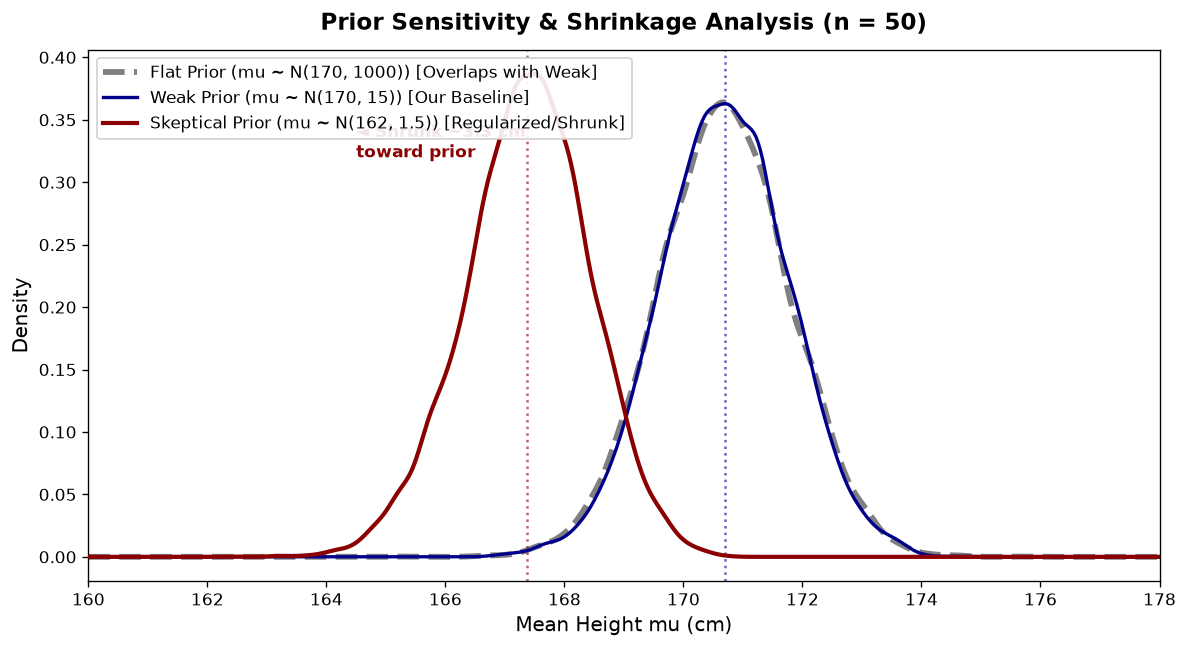

Flat Prior Posterior Mean:      170.68 cm
Weak Prior Posterior Mean:      170.70 cm
Skeptical Prior Posterior Mean: 167.38 cm (Shrunk ~3.3 cm toward 162 cm!)


In [12]:
# Compute posterior under Flat Prior
lp_flat = log_lik + stats.norm.logpdf(grid_mu, 170, 1000) + stats.uniform.logpdf(grid_sigma, 0, 30)
p_flat = np.exp(lp_flat - np.max(lp_flat))
p_flat /= np.sum(p_flat)
mu_flat = grid_mu[np.random.choice(len(grid_mu), size=int(1e4), replace=True, p=p_flat)]

# Compute posterior under Skeptical Prior (mu ~ Normal(162, 1.5))
# A strong prior with small SD (1.5 cm) that pulls noticeably away from the data mean
lp_skep = log_lik + stats.norm.logpdf(grid_mu, 162, 1.5) + stats.uniform.logpdf(grid_sigma, 0, 30)
p_skep = np.exp(lp_skep - np.max(lp_skep))
p_skep /= np.sum(p_skep)
mu_skep = grid_mu[np.random.choice(len(grid_mu), size=int(1e4), replace=True, p=p_skep)]

# Plot Sensitivity Comparison
plt.figure(figsize=(10, 5.5), dpi=120)
kde_flat = stats.gaussian_kde(mu_flat)
kde_weak = stats.gaussian_kde(posterior_mu)
kde_skep = stats.gaussian_kde(mu_skep)

# Focus evaluation tightly on the relevant range [160, 178] cm
x_eval = np.linspace(160, 178, 500)

# 1. Plot Flat Prior with a thick dashed gray line so it remains clearly visible underneath the solid blue line
plt.plot(x_eval, kde_flat(x_eval), color='gray', linestyle='--', linewidth=3.5, label='Flat Prior (mu ~ N(170, 1000)) [Overlaps with Weak]', zorder=2)

# 2. Plot Weak Prior with a solid blue line
plt.plot(x_eval, kde_weak(x_eval), color='darkblue', linestyle='-', linewidth=2.0, label='Weak Prior (mu ~ N(170, 15)) [Our Baseline]', zorder=3)

# 3. Plot Skeptical Prior with a solid red line
plt.plot(x_eval, kde_skep(x_eval), color='darkred', linestyle='-', linewidth=2.5, label='Skeptical Prior (mu ~ N(162, 1.5)) [Regularized/Shrunk]', zorder=4)

# Reference dashed vertical lines showing shrinkage
plt.axvline(np.mean(posterior_mu), color='darkblue', linestyle=':', alpha=0.6)
plt.axvline(np.mean(mu_skep), color='darkred', linestyle=':', alpha=0.6)
plt.text(164.5, 0.32, "◄ Shrunk ~3.3 cm\ntoward prior", color='darkred', fontsize=10, fontweight='bold')

plt.title("Prior Sensitivity & Shrinkage Analysis (n = 50)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Mean Height mu (cm)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(160, 178)
plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=10)
plt.tight_layout()
plt.show()

print(f"Flat Prior Posterior Mean:      {np.mean(mu_flat):.2f} cm")
print(f"Weak Prior Posterior Mean:      {np.mean(posterior_mu):.2f} cm")
print(f"Skeptical Prior Posterior Mean: {np.mean(mu_skep):.2f} cm (Shrunk ~3.3 cm toward 162 cm!)")


## Part 6: Common Traps & FAQs

### Q1: Why are the Frequentist CI and Bayesian Credible Interval nearly identical here?
- **The Bernstein-von Mises Theorem**: Under weakly informative priors and moderate sample sizes ($n=50$), the Likelihood dominates the prior. When likelihood is Gaussian, the Bayesian posterior and Frequentist sampling distribution are asymptotically identical.
- **The Difference is in the Meaning**: Frequentist CI = coverage rate over infinite repeated experiments. Bayesian CI = direct epistemic probability of $\mu$ given this dataset.

### Q2: Why do Frequentists divide by $\sqrt{n}$, but Bayesians don't?
- In Frequentist formulas, $\text{SE} = s / \sqrt{n}$ is derived analytically.
- In Bayesian inference, we multiply $n$ likelihood terms together. The sum of $n$ squared error terms $(y_i - \mu)^2$ inside the exponential naturally concentrates the posterior variance by a factor of $\frac{1}{n}$, giving standard deviation $\frac{\sigma}{\sqrt{n}}$ **automatically without anyone writing $\sqrt{n}$ in the code!**

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): Credible Intervals vs. Frequentist Confidence Intervals
> **Question**: A researcher publishes a paper stating: 
> *"There is a $95\%$ probability that the true average adult height $\mu$ lies between $172\text{ cm}$ and $178\text{ cm}$."*
> - Is this statement statistically valid for a **Bayesian $95\%$ Credible Interval**?
> - Is this statement statistically valid for a **Frequentist $95\%$ Confidence Interval**? Explain why or why not.

In [13]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
# Reflect on the statement:
# "There is a 95% probability that the true parameter mu lies between 172 cm and 178 cm."

# 1. Is this valid for a Bayesian Credible Interval? (True / False)
bayesian_valid = None

# 2. Is this valid for a Frequentist Confidence Interval? (True / False)
frequentist_valid = None

# Write your reasoning in comments or print statements below:


<details>
<summary><b>🔍 Click here to view the solution & rationale</b></summary>

**Answer**:
- **Bayesian Credible Interval: YES**. Under the Bayesian paradigm, the true parameter $\mu$ is a random variable conditional on the observed data. The statement $P(172 \le \mu \le 178 \mid D) = 0.95$ is literal and mathematically sound.
- **Frequentist Confidence Interval: NO (Strictly Invalid)**. In frequentist statistics, the parameter $\mu$ is a fixed, non-random physical constant. The interval $[172, 178]$ is also fixed once observed. Therefore, the parameter is either inside the interval ($P=1$) or outside ($P=0$). The $95\%$ confidence level refers solely to the **long-run procedure frequency** across hypothetical repeated identical experiments.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Measuring Prior Shrinkage
> **Scenario**: Suppose your prior on adult height is $\text{Normal}(\mu_0 = 170\text{ cm}, \sigma_0 = 5\text{ cm})$. 
> You observe a single individual who is unusually tall: $y = 195\text{ cm}$, measured with instrument noise $\sigma = 5\text{ cm}$.
> Calculate the exact analytical posterior mean $\mu_{\text{post}}$ and quantify the shrinkage.

In [14]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
# Prior: Normal(mu_0 = 170, sigma_0 = 5)
# Observation: y = 195, noise sigma = 5

mu_0, sigma_0 = 170.0, 5.0
y, sigma = 195.0, 5.0

# TODO: Calculate the posterior mean
# Hint: When prior variance == likelihood variance, weights are equal (0.5 and 0.5)
# post_mean = ...

# print(f"Posterior Mean: {post_mean:.1f} cm")


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Exact Derivation**:
Under conjugate normal-normal updating with known $\sigma$:
$$\tau_0 = \frac{1}{\sigma_0^2} = \frac{1}{25}, \quad \tau_L = \frac{1}{\sigma^2} = \frac{1}{25}$$
$$\mu_{\text{post}} = \frac{\tau_0 \mu_0 + \tau_L y}{\tau_0 + \tau_L} = \frac{\frac{1}{25}(170) + \frac{1}{25}(195)}{\frac{2}{25}} = \frac{170 + 195}{2} = 182.5\text{ cm}$$

```python
# Prior: Normal(mu_0=170, sigma_0=5), Likelihood noise: sigma=5
mu_0, sigma_0 = 170.0, 5.0
y, sigma = 195.0, 5.0
# Equal variances -> exact midpoint
post_mean = (mu_0 + y) / 2.0
print(f'Posterior Mean: {post_mean:.1f} cm (Shrunk 12.5 cm toward prior mean)')
```

**Shrinkage Analysis**: The prior regularizes the extreme outlier, pulling the point estimate **$12.5\text{ cm}$** inward toward the prior mean.
</details>

---

### 🔴 Tier 3 (Production Challenge): The Curse of Dimensionality in Grid Approximation
> **Scenario**: Suppose you want to estimate a hierarchical Bayesian model with $D$ parameters. You evaluate each parameter over a moderately fine grid of $K = 500$ points.
> 1. Compute the total number of grid point evaluations required for $D = 1, 2, 5, 10$.
> 2. If each likelihood evaluation takes $1\text{ microsecond}$ ($10^{-6}\text{ s}$), how long does grid approximation take for $D = 10$?
> 3. Why does MCMC (Metropolis-Hastings, HMC) bypass this curse?

In [15]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
K = 500  # grid points per dimension

# 1. Compute total grid evaluations for D = [1, 2, 5, 10]
# for D in [1, 2, 5, 10]:
#     total_evals = K ** D
#     print(f"D = {D:2d}: {total_evals:.2e} evaluations")

# 2. Compute evaluation time for D = 10 at 1 microsecond (1e-6 s) per point:
# time_seconds = (K ** 10) * 1e-6
# time_years = time_seconds / (365.25 * 24 * 3600)
# print(f"Time for D = 10: {time_years:.2e} years")


<details>
<summary><b>🔍 Click here to view the solution & scaling analysis</b></summary>

**Scaling Analysis**:
1. **Total Evaluations**:
   - $D = 1$: $500^1 = 500$ points (Instant, $< 1\text{ ms}$).
   - $D = 2$: $500^2 = 250,000$ points ($0.25\text{ s}$).
   - $D = 5$: $500^5 = 3.125 \times 10^{13}$ points ($\approx 361\text{ days}$ of continuous compute).
   - $D = 10$: $500^{10} = 9.77 \times 10^{26}$ points!
2. **Compute Time for $D = 10$**:
   $$\text{Time} = 9.77 \times 10^{26} \times 10^{-6}\text{ s} \approx 9.77 \times 10^{20}\text{ seconds} \approx 31 \times 10^{12}\text{ years}$$
   This is **over 2,000 times the age of the universe**!
3. **Why MCMC Bypasses the Curse**:
   Grid approximation blindly covers the entire parameter volume, $99.999999\%$ of which has near-zero posterior probability density in high dimensions. MCMC, conversely, uses directed random walks (or Hamiltonian gradient physics) to spend $100\%$ of its time navigating exclusively inside the **narrow typical set** where the posterior probability mass actually lives.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 1: Foundations & Exact Conjugate Updating](01_foundations_and_conjugate_updating.ipynb) | ⏭️ Next: [Sheet 3: Rapid Prototyping — Quadratic (Laplace / QUAP) Approx](03_quadratic_laplace_approximation.ipynb)**